# Questão 2 - Visualização de dados

In [3]:
# Carregando o dataset e criando paleta de cores consistentes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Carregando o dataset e limpando o dataset de dados repetidos
df = pd.read_csv("precos_carros_brasil.csv", low_memory=False)
df = df.dropna(how='all').drop_duplicates()

# Paleta de cores consistentes
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4']

print("Dataset pronto:", df.shape)

Dataset pronto: (202295, 11)


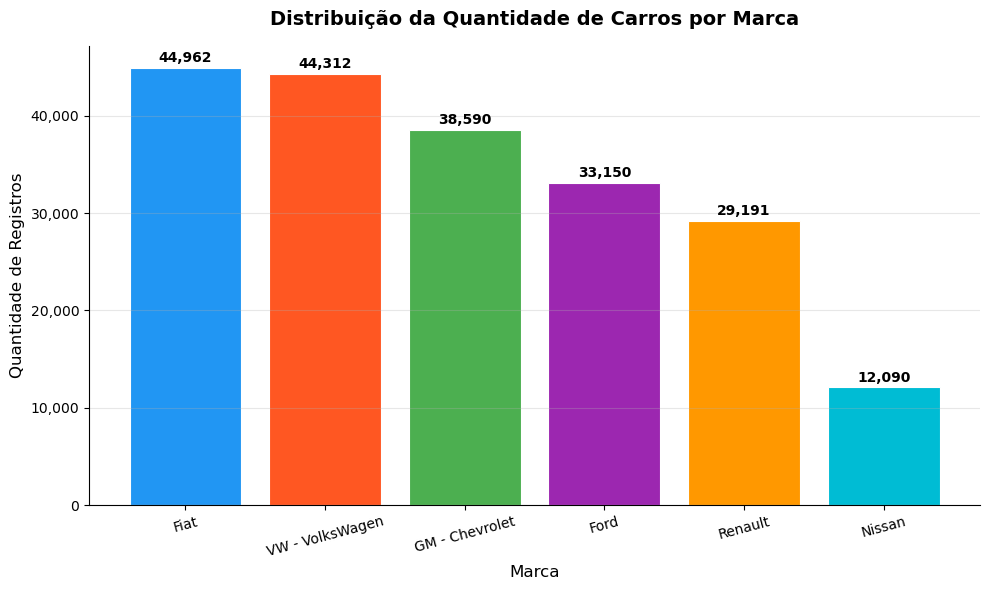

In [5]:
# 2.a) Gerando um gráfico de distribuição da quantidade de carros por marca
contagem_marca = df['brand'].value_counts()

# Criação dos gráficos de barra
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(contagem_marca.index, contagem_marca.values, color=PALETTE, edgecolor='white', linewidth=0.8)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Configuração do gráfico de barra
ax.set_title('Distribuição da Quantidade de Carros por Marca', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Marca', fontsize=12)
ax.set_ylabel('Quantidade de Registros', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=15)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

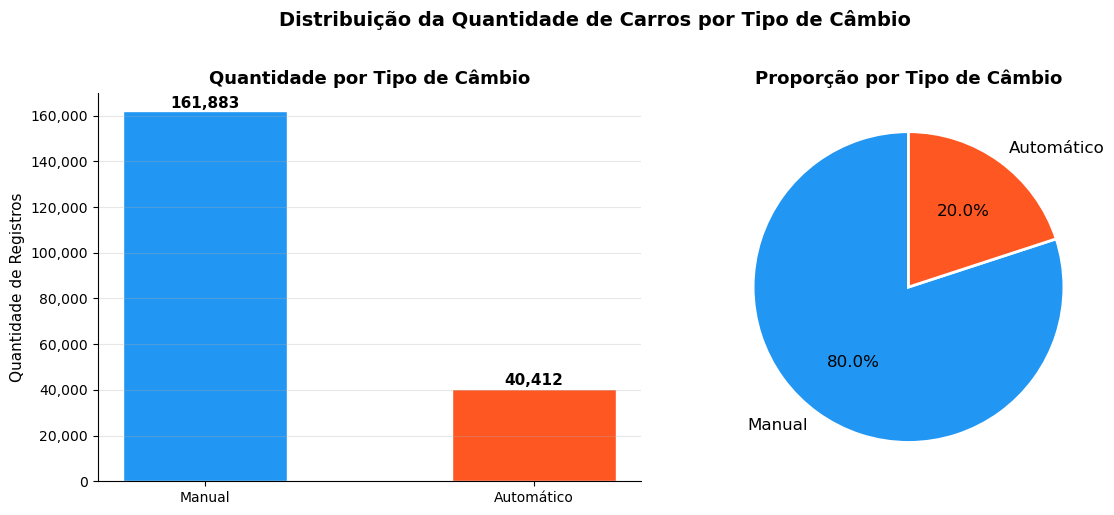

In [6]:
# 2.b) Gerar um gráfico de distribuição da quantidade de carros por marca
contagem_gear = df['gear'].value_counts()
labels_pt = {'manual': 'Manual', 'automatic': 'Automático'}
labels = [labels_pt.get(x, x) for x in contagem_gear.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
bars = axes[0].bar(labels, contagem_gear.values, color=['#2196F3', '#FF5722'], edgecolor='white', width=0.5)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Quantidade por Tipo de Câmbio', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Quantidade de Registros', fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pizza
axes[1].pie(contagem_gear.values, labels=labels, autopct='%1.1f%%',
            colors=['#2196F3', '#FF5722'], startangle=90,
            textprops={'fontsize': 12}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção por Tipo de Câmbio', fontsize=13, fontweight='bold')

fig.suptitle('Distribuição da Quantidade de Carros por Tipo de Câmbio', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

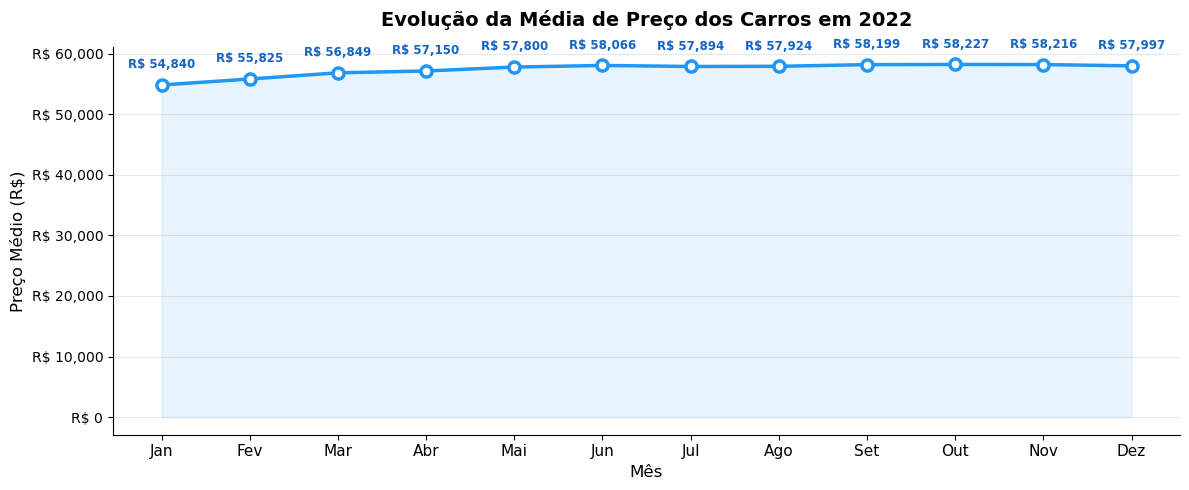

In [9]:
# 2.c) Gerar um gráfico da evolução da média de preço dos carros ao longo dos meses de 2022

# Traduzir os meses de inglês para português
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
month_pt = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

# Setar o ano de 2022 como ano de referência para criar o gráfico de evolução
df_2022 = df[df['year_of_reference'] == 2022].copy()
df_2022['month_of_reference'] = pd.Categorical(df_2022['month_of_reference'], categories=month_order, ordered=True)
media_mensal = df_2022.groupby('month_of_reference', observed=True)['avg_price_brl'].mean()

# Configuração do gráfico de evolução
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(len(media_mensal)), media_mensal.values, marker='o', color='#2196F3',
        linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2.5)
ax.fill_between(range(len(media_mensal)), media_mensal.values, alpha=0.1, color='#2196F3')

for i, v in enumerate(media_mensal.values):
    ax.annotate(f'R$ {v:,.0f}', (i, v), textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=8.5, fontweight='bold', color='#1565C0')

# Criação do gráfico de evolução
ax.set_xticks(range(len(media_mensal)))
ax.set_xticklabels(month_pt, fontsize=11)
ax.set_title('Evolução da Média de Preço dos Carros em 2022', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mês', fontsize=12)
ax.set_ylabel('Preço Médio (R$)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

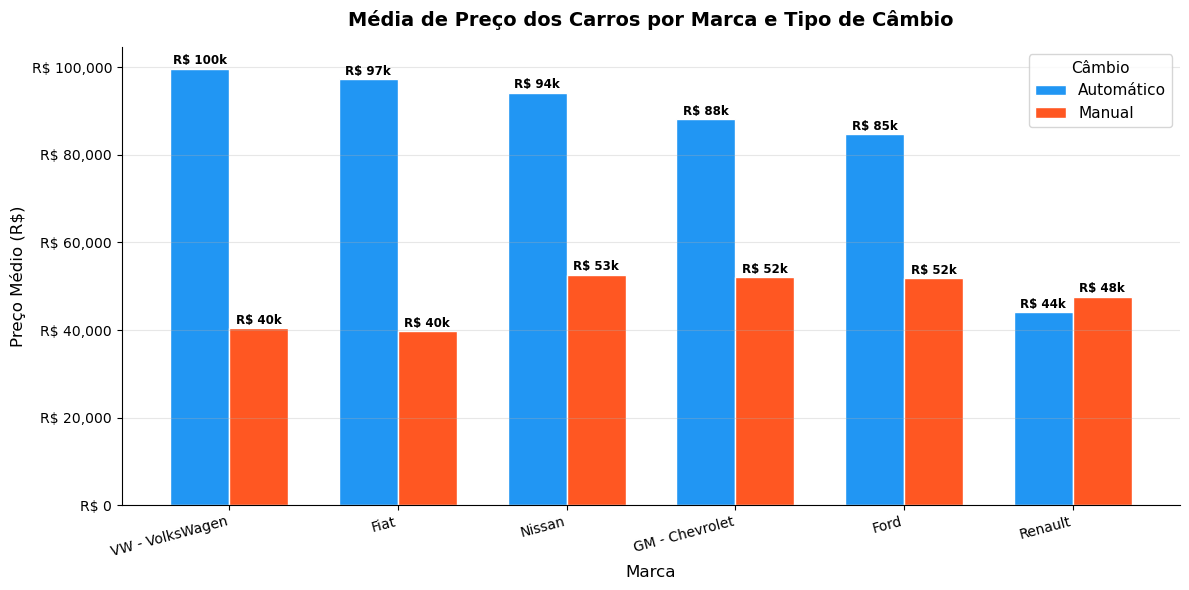

In [10]:
# 2.d) Gerar um gráfico de distribuição da média de preço dos carros por marca e tipo de engrenagem

# Criação das médias de tipo de engrenagem por marca
media_marca_gear = df.groupby(['brand', 'gear'])['avg_price_brl'].mean().unstack()

# Agrupar as colunas por automático e manual
media_marca_gear.columns = ['Automático', 'Manual']
media_marca_gear = media_marca_gear.sort_values('Automático', ascending=False)

x = range(len(media_marca_gear))
width = 0.35

# Configuração do gráfico 
fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar([i - width/2 for i in x], media_marca_gear['Automático'],
               width, label='Automático', color='#2196F3', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], media_marca_gear['Manual'],
               width, label='Manual', color='#FF5722', edgecolor='white')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
            f'R$ {bar.get_height()/1000:.0f}k', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# Criação do gráfico
ax.set_xticks(list(x))
ax.set_xticklabels(media_marca_gear.index, rotation=15, ha='right', fontsize=10)
ax.set_title('Média de Preço dos Carros por Marca e Tipo de Câmbio', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Marca', fontsize=12)
ax.set_ylabel('Preço Médio (R$)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.legend(title='Câmbio', fontsize=11, title_fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**2.e)** Em todas as marcas, veículos com câmbio automático têm preço médio superior ao manual, refletindo maior custo tecnológico e perfil premium. A VW apresenta a maior diferença entre os câmbios enquanto que Renault apresenta a menor diferença entre os câmbios. VW e Fiat apresentam maior diferença de valor entre câmbios indicando que os modelos de câmbio manual são voltados para pessoas de baixa renda.

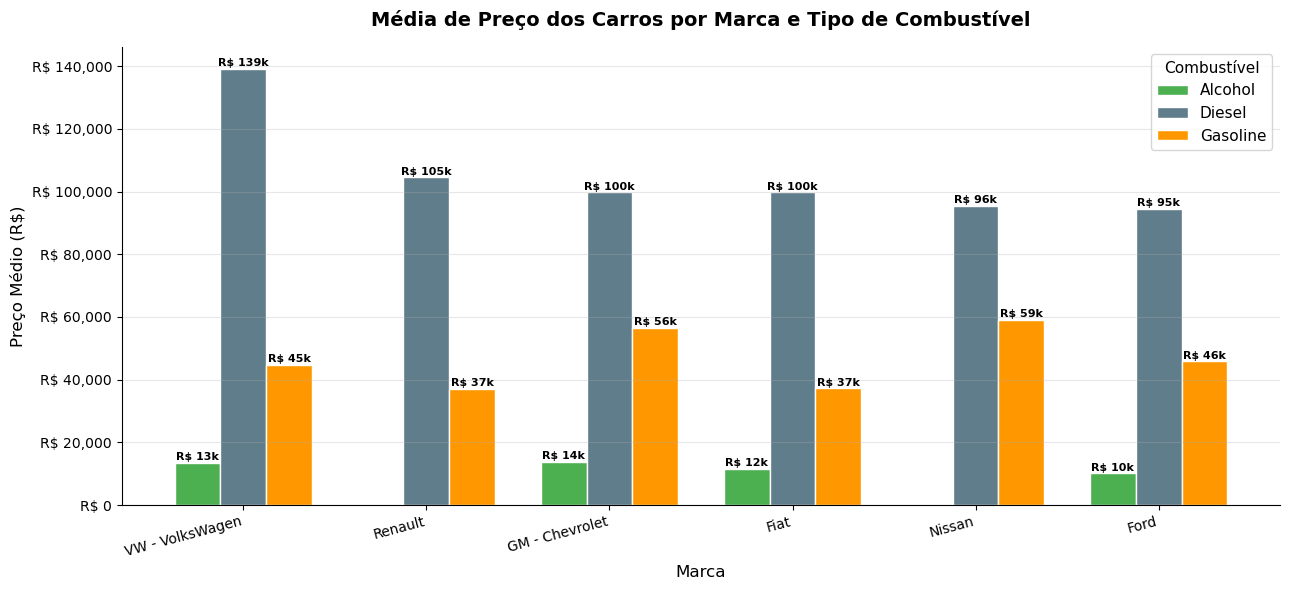

In [14]:
# 2.f) Gerar um gráfico de distribuição da média de preço dos carros por marca e tipo de combustível

# Criar as variáveis de média de combustível por marca de carro
media_marca_fuel = df.groupby(['brand', 'fuel'])['avg_price_brl'].mean().unstack()
media_marca_fuel = media_marca_fuel.sort_values('Diesel' if 'Diesel' in media_marca_fuel.columns else media_marca_fuel.columns[0], ascending=False)

# Configuração das cores do gráfico de barras para distinguir os combustíveis
fuel_colors = {'Gasoline': '#FF9800', 'Alcohol': '#4CAF50', 'Diesel': '#607D8B'}
x = range(len(media_marca_fuel))
n_fuels = len(media_marca_fuel.columns)
width = 0.25

# Configuração geral do gráfico associando a variável da média de combustíveis com o gráfico de barras
fig, ax = plt.subplots(figsize=(13, 6))
for i, fuel in enumerate(media_marca_fuel.columns):
    offset = (i - n_fuels / 2 + 0.5) * width
    bars = ax.bar([xi + offset for xi in x], media_marca_fuel[fuel],
                  width, label=fuel, color=fuel_colors.get(fuel, '#9E9E9E'), edgecolor='white')
    for bar in bars:
        height = bar.get_height()
        if not (height != height):  # ignora NaN
            ax.text(bar.get_x() + bar.get_width() / 2, height + 200,
                    f'R$ {height/1000:.0f}k', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Criação e disposição do gráfico
ax.set_xticks(list(x))
ax.set_xticklabels(media_marca_fuel.index, rotation=15, ha='right', fontsize=10)
ax.set_title('Média de Preço dos Carros por Marca e Tipo de Combustível', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Marca', fontsize=12)
ax.set_ylabel('Preço Médio (R$)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.legend(title='Combustível', fontsize=11, title_fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**2.g)** Os veículos a Diesel apresentam no geral a maior média de preço em todas as marcas que oferecem a opção. A Volkswagen apresenta a maior média devido a seu segmento de caminhonetes e utilitários no segmento. Carros a gasolina ocupam posição intermediária enquanto veículos a álcool ocupam posições menores. Nissan e Renault não apresentam opções a álcool o que é estranho devido a seu foco em carros urbanos e de passeio. 